In [9]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from src.qsp_builder import build_qsp_unitary
from src.recover import build_corrected_qsp_phase_list

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.11.15
qiskit: 2.2.3
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.41.1


In [10]:

env_path = Path("key.env")
if not env_path.exists():
    env_path = Path("../key.env")
load_dotenv(env_path, override=True)

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=os.environ["API_KEY"],
    instance=os.getenv("IBM_QUANTUM_INSTANCE"),
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService()
print(service.active_account())


qiskit_runtime_service._resolve_cloud_instances:WARNING:2026-04-22 19:35:02,221: Default instance not set. Searching all available instances.


{'channel': 'ibm_quantum_platform', 'url': 'https://cloud.ibm.com', 'token': 'lpKyyvWbW5cpF_WVjhoF000NTAXG3SajgDxokoymu6g-', 'verify': True, 'private_endpoint': False}


In [11]:
def qsp_circuit_from_phases(phases, theta):
    qc = QuantumCircuit(1)
    qc.rz(-2 * float(phases[0]), 0)
    for phi in phases[1:]:
        qc.rx(-2 * float(theta), 0)
        qc.rz(-2 * float(phi), 0)
    return qc


def p0_from_counts(counts, shots):
    return counts.get("0", 0) / shots

In [12]:
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=1,
)
print("Backend:", backend.name)

Backend: ibm_fez


Job ID: d7klmsi4lglc73fvkeqg
a^2=0.100 | ideal=0.271000 | base=0.288000 | corr=0.294000
a^2=0.103 | ideal=0.278779 | base=0.334000 | corr=0.317000
a^2=0.106 | ideal=0.286503 | base=0.331000 | corr=0.287000
a^2=0.110 | ideal=0.294172 | base=0.343000 | corr=0.348000
a^2=0.113 | ideal=0.301785 | base=0.302000 | corr=0.333000
a^2=0.116 | ideal=0.309344 | base=0.342000 | corr=0.339000
a^2=0.119 | ideal=0.316847 | base=0.347000 | corr=0.355000
a^2=0.122 | ideal=0.324296 | base=0.382000 | corr=0.335000
a^2=0.126 | ideal=0.331691 | base=0.348000 | corr=0.395000
a^2=0.129 | ideal=0.339032 | base=0.371000 | corr=0.388000
a^2=0.132 | ideal=0.346318 | base=0.375000 | corr=0.359000
a^2=0.135 | ideal=0.353551 | base=0.381000 | corr=0.361000
a^2=0.139 | ideal=0.360731 | base=0.398000 | corr=0.387000
a^2=0.142 | ideal=0.367857 | base=0.409000 | corr=0.399000
a^2=0.145 | ideal=0.374930 | base=0.416000 | corr=0.394000
a^2=0.148 | ideal=0.381949 | base=0.388000 | corr=0.408000
a^2=0.151 | ideal=0.388917 

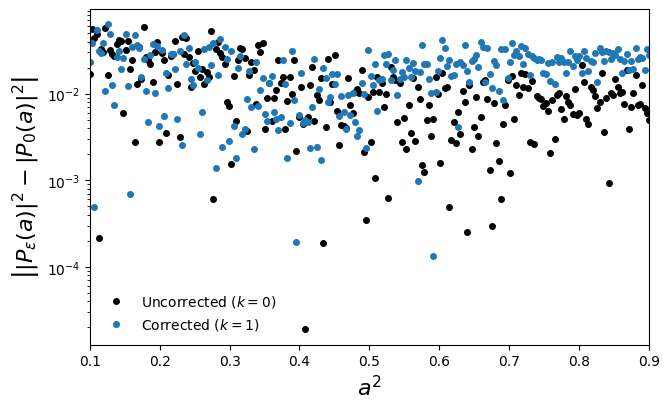

In [ ]:
base_phases = [np.pi / 3] * 4
corr_phases = build_corrected_qsp_phase_list(base_phases)

n_points = 250
shots = 1000
a2_grid = np.linspace(0.1, 0.9, n_points)

circuits = []
ideal_probs = []

for a2 in a2_grid:
    theta = np.arccos(np.sqrt(a2))

    # ideal reference is the noiseless qsp
    ideal_unitary = build_qsp_unitary(base_phases, theta, 0.0)
    ideal_probs.append(abs(ideal_unitary[0, 0]) ** 2)

    base_qc = qsp_circuit_from_phases(base_phases, theta)
    corr_qc = qsp_circuit_from_phases(corr_phases, theta)

    base_qc.measure_all()
    corr_qc.measure_all()

    circuits.append(base_qc)
    circuits.append(corr_qc)

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=0,
)
isa_circuits = [pm.run(qc) for qc in circuits]

sampler = Sampler(mode=backend)
job = sampler.run(isa_circuits, shots=shots)

print("Job ID:", job.job_id())

result = job.result()

base_error = np.zeros_like(a2_grid, dtype=float)
corr_error = np.zeros_like(a2_grid, dtype=float)

for i, a2 in enumerate(a2_grid):
    base_counts = result[2 * i].data.meas.get_counts()
    corr_counts = result[2 * i + 1].data.meas.get_counts()

    p0_base = p0_from_counts(base_counts, shots)
    p0_corr = p0_from_counts(corr_counts, shots)
    p0_ideal = ideal_probs[i]

    base_error[i] = abs(p0_base - p0_ideal)
    corr_error[i] = abs(p0_corr - p0_ideal)

    print(
        f"a^2={a2:.3f} | ideal={p0_ideal:.6f} | "
        f"base={p0_base:.6f} | corr={p0_corr:.6f}"
    )

plt.figure(figsize=(6.8, 4.2))
plt.semilogy(a2_grid, base_error, "ko", ms=4, label=r"Uncorrected ($k=0$)")
plt.semilogy(a2_grid, corr_error, ".", color="tab:blue", ms=8, label=r"Corrected ($k=1$)")
plt.xlabel(r"$a^2$", fontsize=16)
plt.ylabel(r"$\left||P_\epsilon(a)|^2 - |P_0(a)|^2\right|$", fontsize=16)
plt.xlim(a2_grid.min(), a2_grid.max())
plt.legend(frameon=False)
plt.tight_layout()
plt.show()